# Investigation 03 - Clustered Metric Correlation Bubble Plot

This notebook generates 4D correlation bubble plots per stage, similar to Investigation 02. Rules defined in the `CLUSTER_MAP` are colored according to their category, while all other rules are plotted in grey.

In [ ]:
import ast
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.patches import Rectangle

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

# ---------- Main toggles ----------
METHOD = "CN"
ORGAN = "Duodenum"   # "Colon", "Duodenum", or None
ORGAN_COLUMN = "Organ"
NO_SELF = True
SUBSET_RULE_ITEMS_MAX = 2
SUBSET_MIN_SUPPORT = 0.0
STAGE_COLUMN = "Clinical score"
FDR_COLUMN = "FDR"
FDR_MAX = 0.05

STAGES = ["Control", "Mild", "Severe"]

# ---------- Bubble thresholds ----------
POS_LEVERAGE_MIN = 0.0
POS_LIFT_MIN = 0.0
NEG_LEVERAGE_MAX = 0.0
NEG_LIFT_MAX = 0.0

# ---------- Bubble display ----------
MIN_SUPPORT_FOR_BUBBLE = 0.0
BUBBLE_SIZE_SCALE = 2000
NOISE_LEVERAGE_ABS = 0.01
NOISE_LIFT_RANGE = (0.8, 1.2)

# ---------- Data path ----------
ALGO = "fpgrowth_old"
DATA_ROOT = fr"results\\full_run\\{ALGO}\\data"
RAW_RESULTS_FILE = os.path.join("..", "..", DATA_ROOT, f"results_{METHOD}.csv")

print("METHOD:", METHOD)
print("ORGAN:", ORGAN)
print("NO_SELF:", NO_SELF)
print("SUBSET_RULE_ITEMS_MAX:", SUBSET_RULE_ITEMS_MAX)
print("SUBSET_MIN_SUPPORT:", SUBSET_MIN_SUPPORT)
print("FDR_MAX:", FDR_MAX)
print("RAW_RESULTS_FILE:", RAW_RESULTS_FILE)

# ---------- Cluster Map ----------
# Paste your rule strings here exactly as they appear in the dataset
CLUSTER_MAP = {
    "Epithelial structure (valid)": [
        "Epithelial -> Goblet",
        "Fibroblast -> Epithelial" # Replaced Epithelial -> Mesenchymal_VIM for sanity check
        "Microphage -> Epithelial"
    ],
    "Fibrosis and Stromal Remodeling (invalid)": [
        "Fibroblast -> SMV",
        "Macrophage -> Fibroblast"
    ],
    "Immune Depletion (invalid)": [
        "Muscle -> CD4T",
        "CD4T -> Plasma"
    ]
}
CLUSTER_COLORS = {
    "Epithelial structure (valid)": "#2ca02c",  # Green
    "Fibrosis and Stromal Remodeling (invalid)": "#d62728", # Red
    "Immune Depletion (invalid)": "#ff7f0e", # Orange
    "Other / Uncategorized": "#808080"
}


METHOD: CN
ORGAN: Duodenum
NO_SELF: True
SUBSET_RULE_ITEMS_MAX: 2
SUBSET_MIN_SUPPORT: 0.0
FDR_MAX: 0.05
RAW_RESULTS_FILE: ..\..\results\\full_run\\fpgrowth_old\\data\results_CN.csv


In [ ]:
def _to_lineage(cell_label):
    cell_label = str(cell_label)
    if cell_label.endswith("+") and "_" in cell_label:
        return cell_label.rsplit("_", 1)[0]
    return cell_label

def _add_organ_metadata(work_df):
    import os
    import pandas as pd
    if "Organ" in work_df.columns:
        return work_df
    mibi_gut_dir_path = os.path.join("..", "..", "data", "MIBIGutCsv")
    biopsy_path = os.path.join(mibi_gut_dir_path, "biopsy_metadata.csv")
    fovs_path = os.path.join(mibi_gut_dir_path, "fovs_metadata.csv")
    if os.path.exists(biopsy_path) and os.path.exists(fovs_path):
        df_biopsy = pd.read_csv(biopsy_path)
        df_fovs = pd.read_csv(fovs_path)
        unique_biopsies = df_fovs[~df_fovs["FOV"].astype(str).str.startswith("S_")][["Patient", "Cohort"]].drop_duplicates().rename(columns={"Patient": "Biopsy_ID"})
        meta = pd.merge(unique_biopsies, df_biopsy[["Biopsy_ID", "Localization"]], on="Biopsy_ID", how="left")
        def get_organ(row):
            if pd.notna(row.get("Localization")): return row["Localization"]
            cohort = str(row.get("Cohort", ""))
            if "Colon" in cohort: return "Colon"
            if "Duodenum" in cohort: return "Duodenum"
            return "Unknown"
        meta["Organ"] = meta.apply(get_organ, axis=1)
        work_df = work_df.merge(meta[["Biopsy_ID", "Organ"]], on="Biopsy_ID", how="left")
    return work_df

def _create_basic_dataset(raw_results_df):
    work_df = raw_results_df.copy()
    work_df = _add_organ_metadata(work_df)

    work_df["ant_items"] = work_df["Antecedents"].apply(ast.literal_eval)
    work_df["con_items"] = work_df["Consequents"].apply(ast.literal_eval)
    work_df["ant_clean"] = work_df["ant_items"].apply(
        lambda items: [str(x).replace("_CENTER", "").replace("_NEIGHBOR", "") for x in items]
    )
    work_df["con_clean"] = work_df["con_items"].apply(
        lambda items: [str(x).replace("_CENTER", "").replace("_NEIGHBOR", "") for x in items]
    )
    work_df["ant_lineage"] = work_df["ant_clean"].apply(lambda items: [_to_lineage(x) for x in items])
    work_df["con_lineage"] = work_df["con_clean"].apply(lambda items: [_to_lineage(x) for x in items])

    if NO_SELF:
        has_overlap = work_df.apply(
            lambda row: len(set(row["ant_lineage"]).intersection(set(row["con_lineage"]))) > 0,
            axis=1,
        )
        work_df = work_df[~has_overlap].copy()

    if SUBSET_RULE_ITEMS_MAX is not None:
        rule_item_count = work_df.apply(lambda row: len(row["ant_clean"]) + len(row["con_clean"]), axis=1)
        work_df = work_df[rule_item_count <= int(SUBSET_RULE_ITEMS_MAX)].copy()

    if SUBSET_MIN_SUPPORT is not None:
        work_df = work_df[work_df["Support"] >= float(SUBSET_MIN_SUPPORT)].copy()

    if ORGAN is not None:
        work_df = work_df[work_df["Organ"].astype(str) == str(ORGAN)].copy()

    if work_df.empty:
        return work_df

    work_df["Rule"] = work_df.apply(
        lambda row: f"{', '.join(row['ant_clean'])} -> {', '.join(row['con_clean'])}",
        axis=1,
    )
    
    rule_to_cluster = {}
    for cluster, rules in CLUSTER_MAP.items():
        for r in rules:
            rule_to_cluster[r] = cluster
            
    work_df["Cluster"] = work_df["Rule"].map(rule_to_cluster).fillna("Other / Uncategorized")

    return work_df

def _build_metric_bubble_df(work_df, stage):
    if work_df.empty:
        return pd.DataFrame()

    metric_df = work_df.copy()
    metric_df = metric_df[metric_df[STAGE_COLUMN].astype(str) == str(stage)].copy()
    
    if metric_df.empty:
        return pd.DataFrame()
        
    metric_df = metric_df[metric_df[FDR_COLUMN] <= FDR_MAX].copy()
    
    metric_df = metric_df[np.isfinite(metric_df["Lift"])].copy()
    metric_df = metric_df[np.isfinite(metric_df["Confidence"])].copy()
    metric_df = metric_df[np.isfinite(metric_df["Support"])].copy()
    metric_df = metric_df[metric_df["Lift"] > 0].copy()

    metric_df["Leverage"] = metric_df["Support"] * (1 - 1 / metric_df["Lift"])
    metric_df = metric_df[np.isfinite(metric_df["Leverage"])].copy()

    metric_df = metric_df.groupby(["Rule", "Cluster"], as_index=False)[
        ["Lift", "Confidence", "Support", "Leverage", FDR_COLUMN]
    ].mean()

    metric_df["Log2_Lift"] = np.log2(metric_df["Lift"])
    metric_df = metric_df[np.isfinite(metric_df["Log2_Lift"])].copy()

    metric_df = metric_df[metric_df["Support"] >= MIN_SUPPORT_FOR_BUBBLE].copy()
    metric_df["Bubble_Size"] = (metric_df["Support"] * BUBBLE_SIZE_SCALE).clip(lower=10)

    return metric_df


In [ ]:
def _plot_metric_bubble_clustered(metric_df, stage):
    if metric_df.empty:
        print(f"No rules for stage {stage} after filtering.")
        return None

    fig, ax = plt.subplots(figsize=(16, 10))

    for cluster, color in CLUSTER_COLORS.items():
        subset = metric_df[metric_df["Cluster"] == cluster]
        if not subset.empty:
            zorder = 3 if cluster == "Other / Uncategorized" else 5
            alpha = 0.6 if cluster == "Other / Uncategorized" else 0.85
            scatter = ax.scatter(
                subset["Leverage"],
                subset["Log2_Lift"],
                s=subset["Bubble_Size"],
                c=color,
                alpha=alpha,
                edgecolors="black",
                linewidths=0.3,
                label=cluster,
                zorder=zorder
            )
            
            if cluster != "Other / Uncategorized":
                try:
                    from adjustText import adjust_text
                    texts = []
                    for _, row in subset.iterrows():
                        texts.append(ax.text(
                            row["Leverage"],
                            row["Log2_Lift"],
                            row["Rule"],
                            color="black",
                            fontsize=9,
                            zorder=6,
                        ))
                    if texts:
                        adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color='gray', lw=0.5), max_iterations=50)
                except ImportError:
                    for _, row in subset.iterrows():
                        ax.text(row["Leverage"], row["Log2_Lift"], row["Rule"], fontsize=8)

    ax.axvline(0, color="gray", linewidth=1.0)
    ax.axhline(0, color="gray", linewidth=1.0)
    ax.axvline(POS_LEVERAGE_MIN, color="tomato", linestyle="--", linewidth=1.0)
    ax.axhline(np.log2(POS_LIFT_MIN), color="tomato", linestyle="--", linewidth=1.0)
    ax.axvline(NEG_LEVERAGE_MAX, color="royalblue", linestyle="--", linewidth=1.0)
    ax.axhline(np.log2(NEG_LIFT_MAX), color="royalblue", linestyle="--", linewidth=1.0)

    x_min, x_max = metric_df["Leverage"].min(), metric_df["Leverage"].max()
    y_min, y_max = metric_df["Log2_Lift"].min(), metric_df["Log2_Lift"].max()

    if x_max > POS_LEVERAGE_MIN and y_max > np.log2(POS_LIFT_MIN):
        pos_rect = Rectangle(
            (POS_LEVERAGE_MIN, np.log2(POS_LIFT_MIN)),
            x_max - POS_LEVERAGE_MIN,
            y_max - np.log2(POS_LIFT_MIN),
            fill=False,
            edgecolor="tomato",
            linewidth=1.2,
        )
        ax.add_patch(pos_rect)

    if x_min < NEG_LEVERAGE_MAX and y_min < np.log2(NEG_LIFT_MAX):
        neg_rect = Rectangle(
            (x_min, y_min),
            NEG_LEVERAGE_MAX - x_min,
            np.log2(NEG_LIFT_MAX) - y_min,
            fill=False,
            edgecolor="royalblue",
            linewidth=1.2,
        )
        ax.add_patch(neg_rect)

    supports = metric_df["Support"].quantile([0.1, 0.5, 0.75, 0.9]).values
    supports = np.unique(supports)
    size_handles = [
        ax.scatter([], [], s=max(s * BUBBLE_SIZE_SCALE, 10), color="gray", alpha=0.5, edgecolors="none")
        for s in supports
    ]
    size_labels = [f"Support {s:.3f}" for s in supports]
    
    cluster_handles = [
        ax.scatter([], [], s=100, color=color, edgecolors="black", label=cluster)
        for cluster, color in CLUSTER_COLORS.items()
    ]
    
    leg1 = ax.legend(handles=cluster_handles, loc="upper left", bbox_to_anchor=(1.05, 1.0), title="Clusters")
    ax.add_artist(leg1)
    ax.legend(handles=size_handles, labels=size_labels, title="Bubble size", loc="upper left", bbox_to_anchor=(1.05, 0.6))

    positive_count = int(((metric_df["Leverage"] >= POS_LEVERAGE_MIN) & (metric_df["Log2_Lift"] >= np.log2(POS_LIFT_MIN))).sum())
    negative_count = int(((metric_df["Leverage"] <= NEG_LEVERAGE_MAX) & (metric_df["Log2_Lift"] <= np.log2(NEG_LIFT_MAX))).sum())
    dot_count = int(metric_df.shape[0])

    organ_text = ORGAN if ORGAN is not None else "All"
    
    title_lines = [
        f"Clustered Metric Correlation Bubble Plot ({METHOD} | {ALGO})",
        f"Organ: {organ_text}  |  Stage Col: {STAGE_COLUMN}  |  Stage: {stage}",
        f"Filters: No Self-Loops={NO_SELF}  |  Max Items={SUBSET_RULE_ITEMS_MAX}  |  Min Support={SUBSET_MIN_SUPPORT}  |  FDR <= {FDR_MAX}"
    ]
    
    ax.set_title(
        "\n".join(title_lines), 
        pad=20, loc="left", fontsize=11, fontweight="bold", linespacing=1.5
    )
    ax.set_xlabel("Leverage")
    ax.set_ylabel("log2(Lift)")
    ax.text(
        0.01,
        -0.12,
        f"Dots: {dot_count} | Positive: {positive_count} | Negative: {negative_count}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10,
    )
    fig.subplots_adjust(bottom=0.16, right=0.7)

    return fig



===================== STAGE: Control =====================


C:\Users\Owner\AppData\Local\Temp\ipykernel_18720\726930636.py:47: RuntimeWarning: divide by zero encountered in log2
  ax.axhline(np.log2(POS_LIFT_MIN), color="tomato", linestyle="--", linewidth=1.0)
C:\Users\Owner\AppData\Local\Temp\ipykernel_18720\726930636.py:49: RuntimeWarning: divide by zero encountered in log2
  ax.axhline(np.log2(NEG_LIFT_MAX), color="royalblue", linestyle="--", linewidth=1.0)
C:\Users\Owner\AppData\Local\Temp\ipykernel_18720\726930636.py:54: RuntimeWarning: divide by zero encountered in log2
  if x_max > POS_LEVERAGE_MIN and y_max > np.log2(POS_LIFT_MIN):
C:\Users\Owner\AppData\Local\Temp\ipykernel_18720\726930636.py:56: RuntimeWarning: divide by zero encountered in log2
  (POS_LEVERAGE_MIN, np.log2(POS_LIFT_MIN)),
C:\Users\Owner\AppData\Local\Temp\ipykernel_18720\726930636.py:58: RuntimeWarning: divide by zero encountered in log2
  y_max - np.log2(POS_LIFT_MIN),
c:\Users\Owner\Documents\script-rule-mining\venv\Lib\site-packages\matplotlib\patches.py:797: Runt

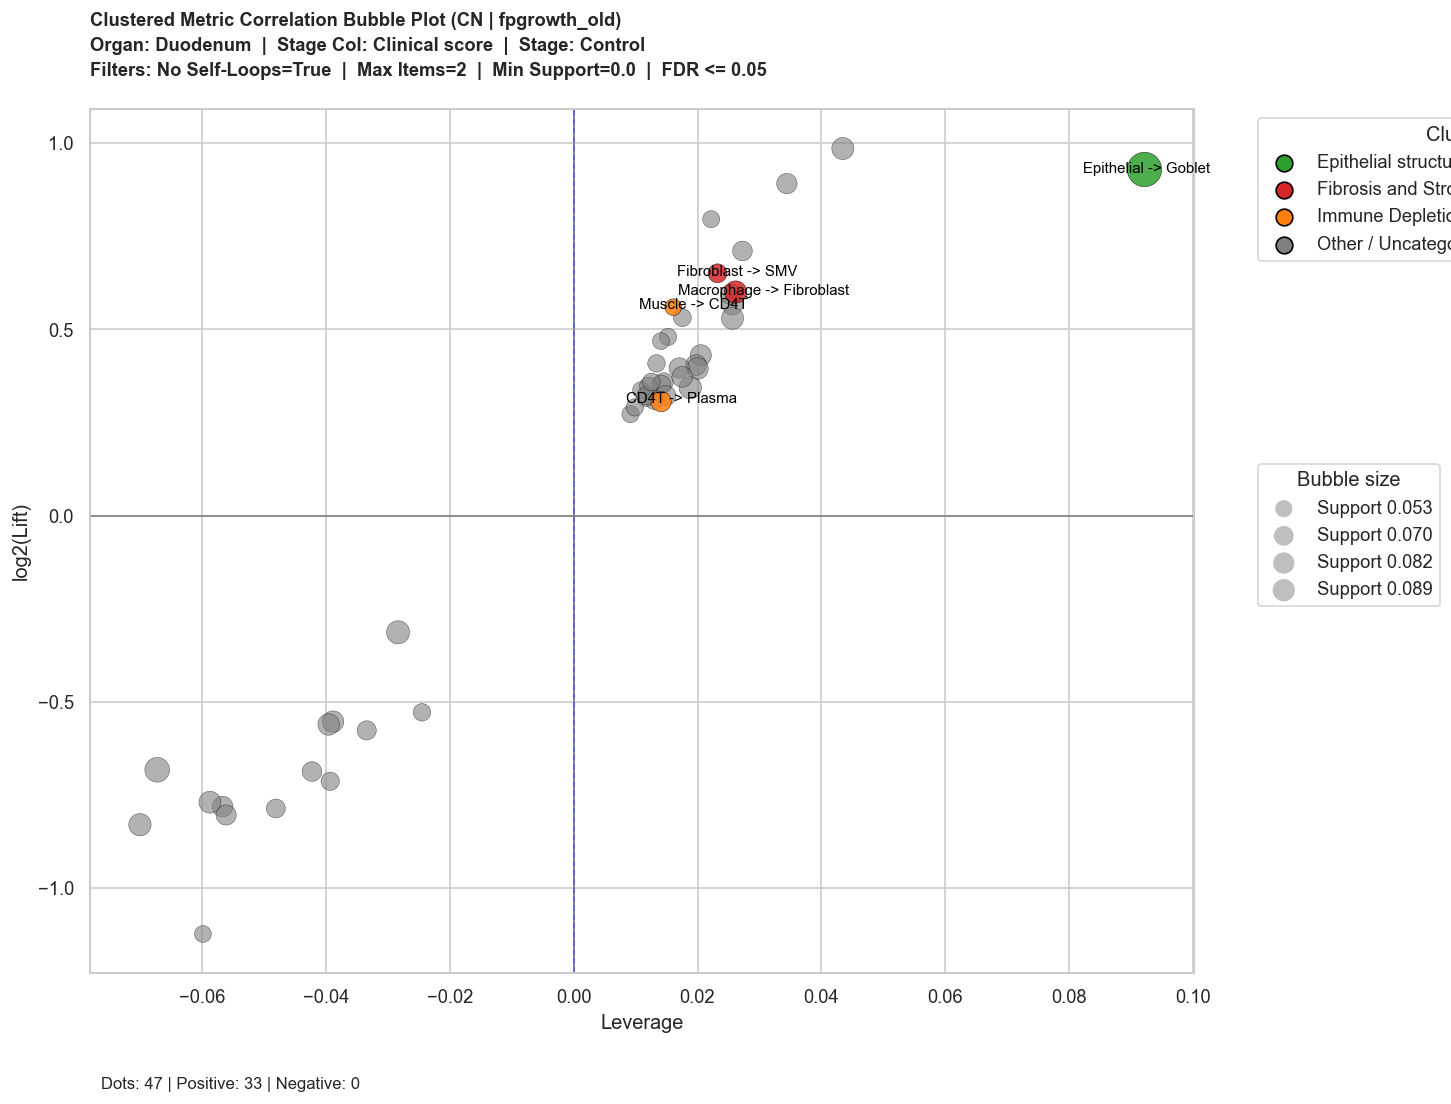

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.



===================== STAGE: Mild =====================


C:\Users\Owner\AppData\Local\Temp\ipykernel_18720\726930636.py:47: RuntimeWarning: divide by zero encountered in log2
  ax.axhline(np.log2(POS_LIFT_MIN), color="tomato", linestyle="--", linewidth=1.0)
C:\Users\Owner\AppData\Local\Temp\ipykernel_18720\726930636.py:49: RuntimeWarning: divide by zero encountered in log2
  ax.axhline(np.log2(NEG_LIFT_MAX), color="royalblue", linestyle="--", linewidth=1.0)
C:\Users\Owner\AppData\Local\Temp\ipykernel_18720\726930636.py:54: RuntimeWarning: divide by zero encountered in log2
  if x_max > POS_LEVERAGE_MIN and y_max > np.log2(POS_LIFT_MIN):
C:\Users\Owner\AppData\Local\Temp\ipykernel_18720\726930636.py:56: RuntimeWarning: divide by zero encountered in log2
  (POS_LEVERAGE_MIN, np.log2(POS_LIFT_MIN)),
C:\Users\Owner\AppData\Local\Temp\ipykernel_18720\726930636.py:58: RuntimeWarning: divide by zero encountered in log2
  y_max - np.log2(POS_LIFT_MIN),
c:\Users\Owner\Documents\script-rule-mining\venv\Lib\site-packages\matplotlib\patches.py:797: Runt

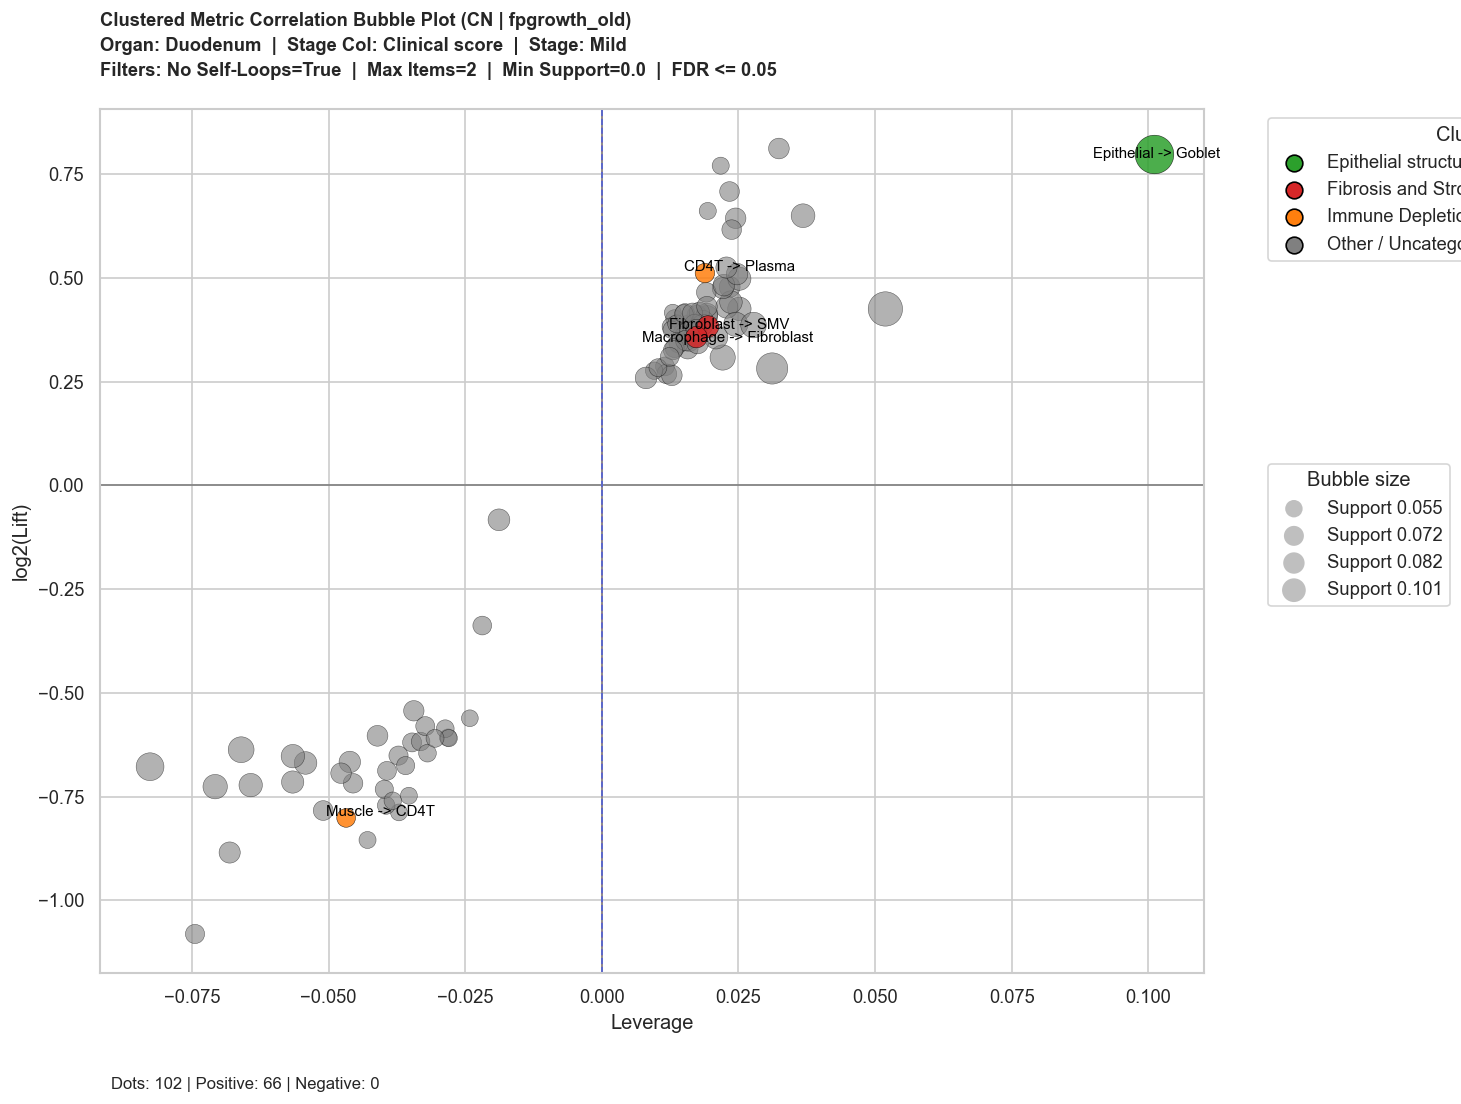


===================== STAGE: Severe =====================


C:\Users\Owner\AppData\Local\Temp\ipykernel_18720\726930636.py:47: RuntimeWarning: divide by zero encountered in log2
  ax.axhline(np.log2(POS_LIFT_MIN), color="tomato", linestyle="--", linewidth=1.0)
C:\Users\Owner\AppData\Local\Temp\ipykernel_18720\726930636.py:49: RuntimeWarning: divide by zero encountered in log2
  ax.axhline(np.log2(NEG_LIFT_MAX), color="royalblue", linestyle="--", linewidth=1.0)
C:\Users\Owner\AppData\Local\Temp\ipykernel_18720\726930636.py:54: RuntimeWarning: divide by zero encountered in log2
  if x_max > POS_LEVERAGE_MIN and y_max > np.log2(POS_LIFT_MIN):
C:\Users\Owner\AppData\Local\Temp\ipykernel_18720\726930636.py:56: RuntimeWarning: divide by zero encountered in log2
  (POS_LEVERAGE_MIN, np.log2(POS_LIFT_MIN)),
C:\Users\Owner\AppData\Local\Temp\ipykernel_18720\726930636.py:58: RuntimeWarning: divide by zero encountered in log2
  y_max - np.log2(POS_LIFT_MIN),
c:\Users\Owner\Documents\script-rule-mining\venv\Lib\site-packages\matplotlib\patches.py:797: Runt

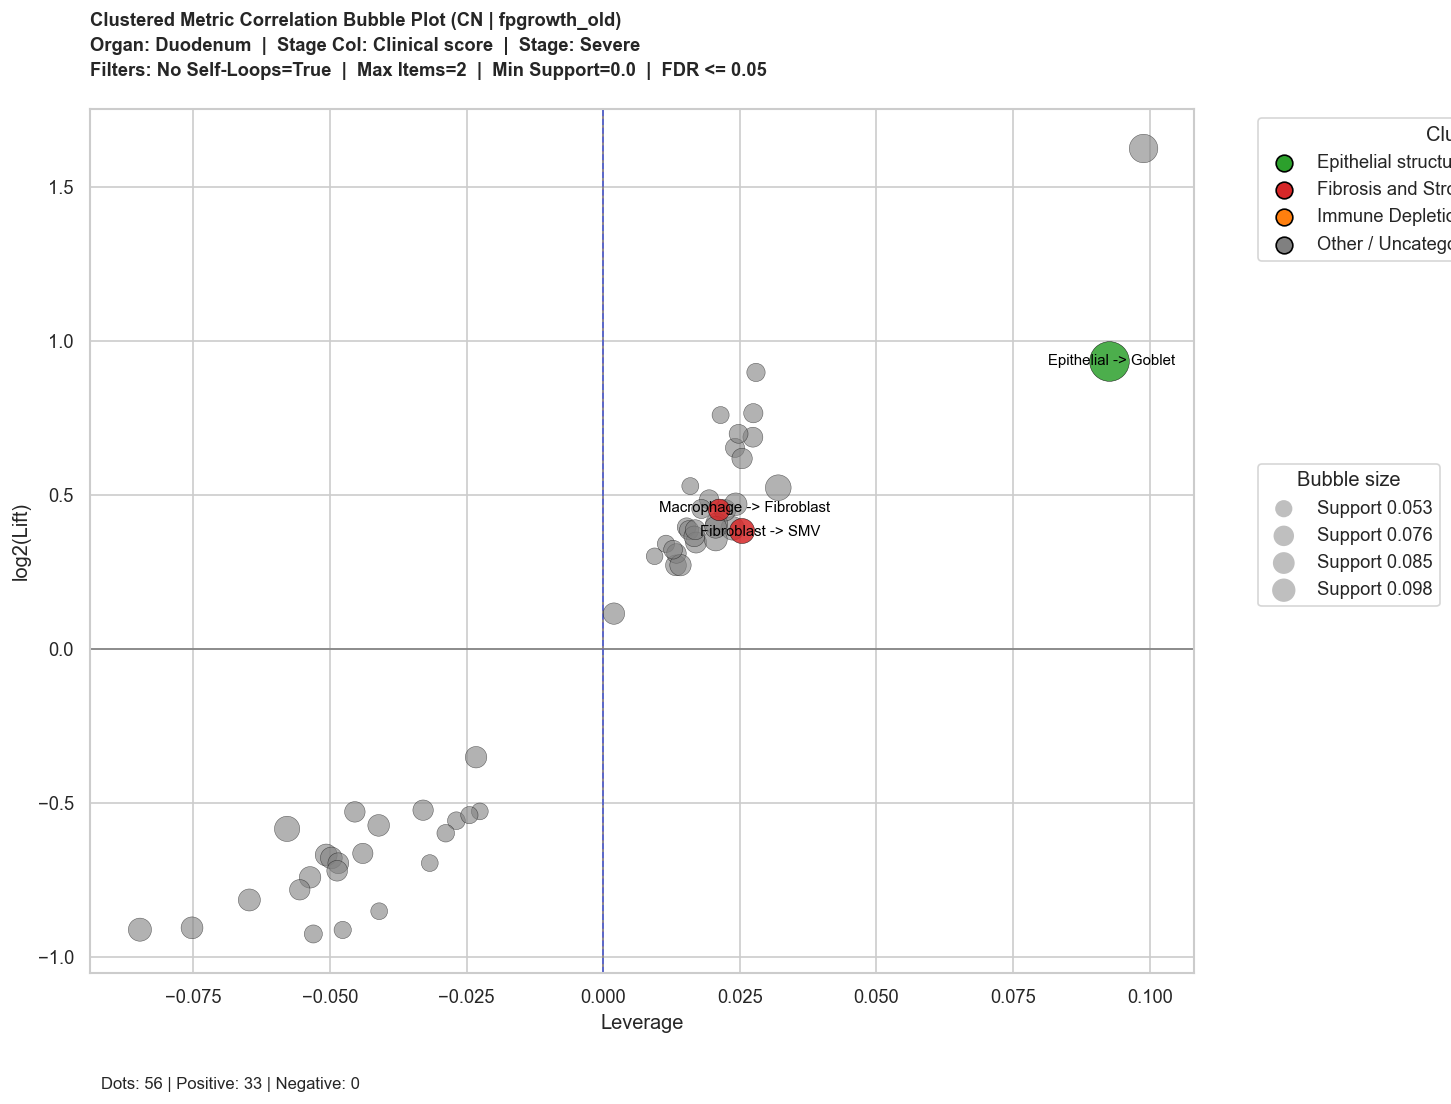

In [ ]:
if os.path.exists(RAW_RESULTS_FILE):
    raw_results_df = pd.read_csv(RAW_RESULTS_FILE)
    work_df = _create_basic_dataset(raw_results_df)

    for stage in STAGES:
        print(f"\n===================== STAGE: {stage} =====================")
        metric_df = _build_metric_bubble_df(work_df, stage)
        if not metric_df.empty:
            fig = _plot_metric_bubble_clustered(metric_df, stage)
            plt.show()
        else:
            print(f"No valid rules found for stage {stage}.")
else:
    print(f"File not found: {RAW_RESULTS_FILE}")
